# Starlink Flyovers over London:

This notebook produces the experimental results used for identifying and visualising Starlink satellite flyovers passing over London, which can be directly compared with a [complementary notebook](03_REACH_Starlink.ipynb) investigating the Starlink population at the Radio Experiment for the Analysis of Cosmic Hydrogen (REACH) site in the Karoo radio reserve. 

### Initialising Satellite Data:

Satellite Two-Line Elements (TLEs) are first loaded and filtered to identify the Starlink satellites relevant within the observation window. Satellite trajectories are propagated using the specified observation durection and temporal resolution, while accounting for London's coordinates with REACH's horizon profile.

In [1]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Time Array:
ts = load.timescale()
length = 3600*1.5 # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London",51.5,0.128], ["REACH",-30.7,-21.5]]

In [3]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=10,
    obs_lat=51.5081,
    obs_lon=-0.128005,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="starlink"
)

Processing satellites:   2%|▏         | 167/7699 [00:41<25:09,  4.99satellite/s]  c:\Users\lette\anaconda3\envs\astrotrack\Lib\site-packages\erfa\core.py:4620: RuntimeWarning: invalid value encountered in ld
  p1 = ufunc.ld(bm, p, q, e, em, dlim)
c:\Users\lette\anaconda3\envs\astrotrack\Lib\site-packages\erfa\core.py:19004: RuntimeWarning: invalid value encountered in anp
  c_retval = ufunc.anp(a)
Processing satellites: 100%|██████████| 7699/7699 [30:54<00:00,  4.15satellite/s]  


In [4]:
n_flyovers = len(data)
norads = []
for flyover in data:
    tle_2 = flyover['TLE'][1].split(" ")  # get NORAD from TLE line 2
    norads.append(tle_2[1])  # append NORADs

print(f"Number of Starlink Flyovers over London: {len(data)}")

Number of Starlink Flyovers over London: 2168


### Plotting Maximum Elevation Angle Distribution Relative to London:

The distribution of $\phi_{\text{max}}$ is plotted to characterise the angular extent of Starlink satellite trajectories relative to London. This secondary location was provided in order to compare whether the number of Starlink flyovers was dependent on the latitudinal and longitudinal coordinates of an instrument set. This is supported by studies suggesting that LEO satellites tend to cluster at the mid-latitudes (Lawler et al. 2022).

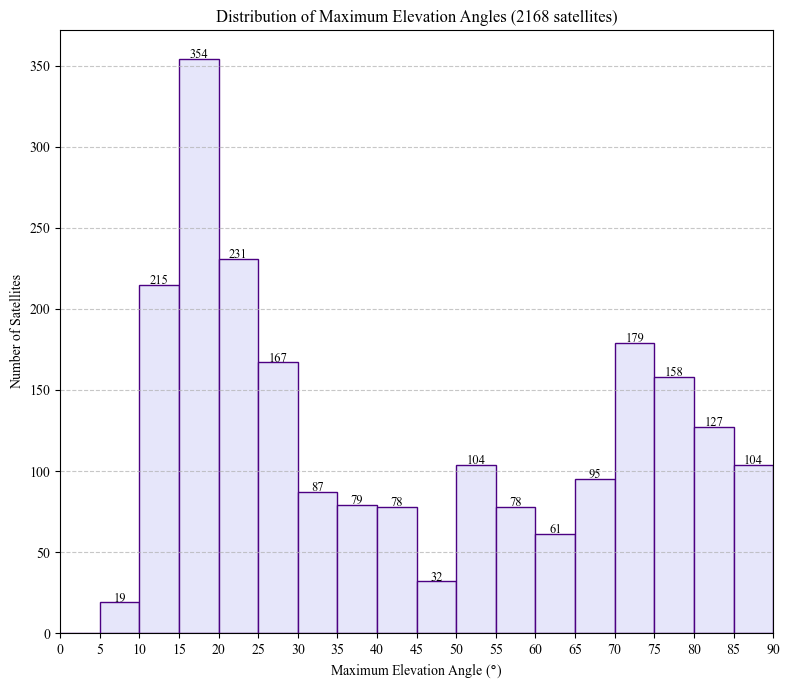

In [10]:
from astrotrack.satcon_properties import plot_max_elevation_histogram

plot_max_elevation_histogram(
    data,
    font_family="Times New Roman",
    figsize=(8, 7),
    color="lavender",
    edgecolor="indigo"
)

### Bibliography

Lawler, S. M., Boley, A. C. & Rein, H. (2022). “Visibility Predictions for Near-future Satellite Megaconstellations: Latitudes near 50° Will Experience the Worst Light Pollution.” The Astronomical Journal, 163(1), 21. 
https://doi.org/10.3847/1538-3881/ac341b